In [1]:
#import the library pulp as p
# import pulp as p
# from pulp import *
import pandas as pd
import numpy as np
import math
from scipy.stats import norm
from scipy.optimize import minimize


#import the necessary functions
from Interpolation_functions import *

# from Functions_for_BS import *
# from Common_functions import *

In [2]:
import gurobipy as gp
from gurobipy import GRB, quicksum
print(gp.gurobi.version())
model = gp.Model()
print("License ID:", model.getParamInfo("LicenseID"))

(12, 0, 1)
Set parameter Username
Set parameter LicenseID to value 2623371
Academic license - for non-commercial use only - expires 2026-02-18
License ID: ('LicenseID', <class 'int'>, 2623371, 0, 2000000000, 0)


In [3]:
#common parameters for all the experiments/GLOBAL VARIABLES

stock = 1 #initial stock price

K = 1 # target option's strike price

r = 0 #risk-free rate of interest

sigma = 0.2 #volatility of the stock price

T = 1 #target maturity

mu = 0 #return of the stock price

t = 0

timepoints =2 #number of timesteps


T_GRID = [0,0.5,T]#times at which the marginals of the stock price are evaluated

short_maturity = T_GRID[1] # maturity of the options in the hedge portfolio


#short_strike_range = [1,1.1,0.9,1.2,0.8,1.25,1.05,0.85,]#range of short strikes for increasing number of options

In [4]:
def Asian_option_payoff(stock_price_t1,stock_price_T,K):
    return np.maximum(stock_price_T - stock_price_t1, 0)

In [5]:
# #function to return the discretization points, call prices and the marginals for a given value of truncation range and number of discretization points and choice of uniform or nonuniform grid

# def get_disc_points_and_marginals(truncation_range=None,n=None, N=None,choice="uniform"):
#     """
#        Generate the discretization points for the given problem depending on uniform or non-uniform grid
#        Parameters: 
#           Global variables: Stock, sigma, T,r,
#           Local variables: n- (1/n) denotes the spacing between the discretization points
                        
#     """
#     if choice == "uniform":
#         if truncation_range == None or n == None:
#             return ("Need to provide n or truncation range")
#         #return a uniform grid
#         D = np.linspace(0, truncation_range, int(truncation_range*n)+1)
        
        
#         #next we find the point where the interpolated line joining the last two strike points takes value zero
#         R_0 = find_zero(BS_call,stock,D,T_GRID[1],sigma,r)
        
# #         print(f"The interpolated line takes the value 0 at {R_0}")
        
#         #print the corresponding call value
# #         print(f"Strike:{R_0},Interpolated call value:{interpolated_line(stock,D,T,sigma,r,R_0)}")
        
        
#         #extending the truncation range to include the new points till the zero of the interpolated call value
#         K1_new = append_numbers(D,D[-1],R_0,np.diff(D)[0])
        
# #         print(f"Extended truncation range for time {t1[1]}:{K1_new}")
# #         print(f"length of new truncation range :{len(K1_new)}")
# #         print(f"previous length:{len(D)}")
        
#         K2_new = append_numbers(D,D[-1],R_0,np.diff(D)[0])
# #         print(f"Extended truncation range for time {t1[2]}:{K2_new}")
# #         print(f"spacing:{K2_new[-2]/(len(K2_new)-2)},{D[-1]/(len(D)-1)}") 
        
        
#         #getting the new discretization points
#         disc_points_new = disc_points_new_1(K1_new,K2_new)
#         print(f"The new discretization points are:{disc_points_new}")
        
#         # store the call prices as a 2D array
#         call_prices_array_new = np.vstack((call_prices(stock,D,K1_new,T_GRID[1],sigma,r),
#                                            call_prices(stock,D,K2_new,T,sigma,r)))
# #         print(call_prices_array_new)
        
#         #getting the discrete marginal distributions

#         marg = marginal_new(call_prices_array_new,disc_points_new,timepoints,T_GRID)
# #         print(marginal_new(call_prices_array_new,disc_points_new,timepoints,t1))
        
        
#         #returns the grid and the number of grid points
#         return disc_points_new,call_prices_array_new,marg
#     else:
#         if N == None:
#             return print("Need to provide N")
#         np.random.seed(12)
#         grid = np.random.normal(K,sigma,N-2)# creating a grid concentrated around the target strike
        
#         grid = np.append([0,truncation_range],grid)# adding 0 and the final truncation point to the list
        
#         grid = np.sort(grid)# sorting the grid in ascending order
        
#          #next we find the point where the interpolated line joining the last two strike points takes value zero
#         R_0_T1 = find_zero(BS_call,stock,grid,T_GRID[1],sigma,r)
#         print(f"The strike for time {T_GRID[1]} is {R_0_T1} and interpolated call value: {interpolated_line(stock,grid,T_GRID[1],sigma,r,R_0_T1)}")
        
#         R_0_T = find_zero(BS_call,stock,grid,T,sigma,r)
#         print(f"The strike for time {T} is {R_0_T} and interpolated call value: {interpolated_line(stock,grid,T,sigma,r,R_0_T)}")
        
#         R_0 = max(R_0_T1,R_0_T)
        
        
# #         #next we find the point where the interpolated line joining the last two strike points takes value zero
# #         R_0 = find_zero(BS_call,stock, grid,T,sigma,r)
        
# #         print(f"The interpolated line takes the value 0 at {R_0}")
        
# #         #print the corresponding call value
# #         print(f"Strike:{R_0},Interpolated call value:{interpolated_line(stock,grid,T,sigma,r,R_0)}")
        
#         new_grid = np.append(grid,[R_0])
        
#         K1_new = K2_new = new_grid
        
#         #getting the new discretization points
#         disc_points_new = disc_points_new_1(K1_new,K2_new)
#         print(f"The new discretization points are:{disc_points_new}")
#         print(f"Number of discretization points are:{len(K1_new)}")
        
                
#         # store the call prices as a 2D array
#         call_prices_array_new = np.vstack((call_prices(stock,grid,K1_new,T_GRID[1],sigma,r),call_prices(stock,grid,K2_new,T,sigma,r)))
        
#         print(f"The call prices are:{call_prices_array_new}")
        
#         #getting the discrete marginal distributions

#         marg = marginal_new(call_prices_array_new,disc_points_new,timepoints,T_GRID)
# #         print(marginal_new(call_prices_array_new,disc_points_new,timepoints,T_GRID))
        
#         #returns the grid and the number of grid points
#         return disc_points_new,call_prices_array_new,marg

In [6]:
#function to return the discretization points, call prices and the marginals for a given value of truncation range and number of discretization points and choice of uniform or nonuniform grid

def get_disc_points_and_marginals(truncation_range=None,n=None, N=None,choice="uniform"):
    """
       Generate the discretization points for the given problem depending on uniform or non-uniform grid
       Parameters: 
          Global variables: Stock, sigma, T,r,
          Local variables: n- (1/n) denotes the spacing between the discretization points
                        
    """
    if choice == "uniform":
        if truncation_range == None or n == None:
            return ("Need to provide n or truncation range")
        #return a uniform grid
        D = np.linspace(0, truncation_range, int(truncation_range*n)+1)
        
        
        #next we find the point where the interpolated line joining the last two strike points takes value zero
        R_0_T1 = find_zero(BS_call,stock,D,T_GRID[1],sigma,r)
        print(f"The strike for time {T_GRID[1]} is {R_0_T1} and interpolated call value: {interpolated_line(stock,D,T_GRID[1],sigma,r,R_0_T1)}")
        
        R_0_T = find_zero(BS_call,stock,D,T_GRID[1],sigma,r)
        print(f"The strike for time {T} is {R_0_T} and interpolated call value: {interpolated_line(stock,D,T,sigma,r,R_0_T)}")
        
        R_0 = max(R_0_T1,R_0_T)
#         print(f"The interpolated line takes the value 0 at {R_0}")
       
        #print the corresponding call value
        print(f"Strike:{R_0},Interpolated call value:{interpolated_line(stock,D,T_GRID[1],sigma,r,R_0)}")
        
        
        #extending the truncation range to include the new points till the zero of the interpolated call value
        K1_new = append_numbers(D,D[-1],R_0,np.diff(D)[0])
        
#         print(f"Extended truncation range for time {t1[1]}:{K1_new}")
#         print(f"length of new truncation range :{len(K1_new)}")
#         print(f"previous length:{len(D)}")
        
        K2_new = append_numbers(D,D[-1],R_0,np.diff(D)[0])
#         print(f"Extended truncation range for time {t1[2]}:{K2_new}")
#         print(f"spacing:{K2_new[-2]/(len(K2_new)-2)},{D[-1]/(len(D)-1)}") 
        
        
        #getting the new discretization points
        disc_points_new = disc_points_new_1(K1_new,K2_new)
        print(f"The new discretization points are:{disc_points_new}")
        
        # store the call prices as a 2D array
        call_prices_array_new = np.vstack((call_prices(stock,D,K1_new,T_GRID[1],sigma,r),call_prices(stock,D,K2_new,T,sigma,r)))
#         print(call_prices_array_new)
        
        #getting the discrete marginal distributions

        marg = marginal_new(call_prices_array_new,disc_points_new,timepoints,T_GRID)
#         print(marginal_new(call_prices_array_new,disc_points_new,timepoints,t1))
        
        
        #returns the grid and the number of grid points
        return disc_points_new,call_prices_array_new,marg
    else:
        if N == None:
            return print("Need to provide N")
        np.random.seed(12)
        grid = np.random.normal(K,sigma,N-2)# creating a grid concentrated around the target strike
        
        grid = np.append([0,truncation_range],grid)# adding 0 and the final truncation point to the list
        
        grid = np.sort(grid)# sorting the grid in ascending order
        
        #next we find the point where the interpolated line joining the last two strike points takes value zero
        R_0_T1 = find_zero(BS_call,stock,grid,T_GRID[1],sigma,r)
        print(f"The strike for time {T_GRID[1]} is {R_0_T1} and interpolated call value: {interpolated_line(stock,grid,T_GRID[1],sigma,r,R_0_T1)}")
        
        R_0_T = find_zero(BS_call,stock,grid,T,sigma,r)
        print(f"The strike for time {T} is {R_0_T} and interpolated call value: {interpolated_line(stock,grid,T,sigma,r,R_0_T)}")
        
        R_0 = max(R_0_T1,R_0_T)
        
#         #next we find the point where the interpolated line joining the last two strike points takes value zero
#         R_0 = find_zero(BS_call,stock, grid,T,sigma,r)
        
#         print(f"The interpolated line takes the value 0 at {R_0}")
        
#         #print the corresponding call value
#         print(f"Strike:{R_0},Interpolated call value:{interpolated_line(stock,grid,T,sigma,r,R_0)}")
        
        new_grid = np.append(grid,[R_0])
        
        K1_new = np.append(grid[:-1],[R_0_T1])
        
        if R_0_T1 <= R_0_T:
            K2_new = np.append(grid[:-1],[R_0_T]) 
        else:
            K2_new = np.append(grid,[R_0_T1]) 
        
#         K1_new, K2_new = np.append(grid,[R_0_T1]),np.append(grid,[R_0_T])
        #getting the new discretization points
        disc_points_new = disc_points_new_1(K1_new,K2_new)
        print(f"The new discretization points are:{disc_points_new}")
        print(f"Number of discretization points are:{len(K1_new)}")
        
                
        # store the call prices as a 2D array
        call_prices_array_new = np.vstack((call_prices_new(stock,grid,K1_new,T_GRID[1],sigma,r),call_prices_new(stock,grid,K2_new,T,sigma,r)))
#         print(call_prices_array_new)
        
        #getting the discrete marginal distributions

        marg = marginal_new(call_prices_array_new,disc_points_new,timepoints,T_GRID)
#         print(marginal_new(call_prices_array_new,disc_points_new,timepoints,T_GRID))
        
        #returns the grid and the number of grid points
        return disc_points_new,call_prices_array_new,marg

In [7]:
def get_target_call(marg, disc_points_new,K):
    """
    returns the price of the target option and the short-maturity options in the hedge portfolio
    Parameters:
       marg: marginal distributions, 
       disc_points_new: the discretization points 
    """
    N = len(disc_points_new[1]) #returns the number of discretization points corresponding to the target maturity
    target_call = sum(marg[1,i] * np.maximum(disc_points_new[1,i]- K,0) for i in range(N))
    return target_call
    


def get_short_call(t1,short_maturity,no_of_options,marg,disc_points_new,short_strikes):
    """
    returns the price of the target option and the short-maturity options in the hedge portfolio
    Parameters:
      t1: list of the time-points given by [0,short_maturity,target_maturity]
      short_maturity: maturity of the options in the hedge portfolio
      no_of_options: numner of options in the hedge portfolio
      marg: marginal distributions
      disc_points_new: discretization points
      short_strikes: strikes of the options in the hedge portfolio
    """
    short_call = np.zeros(no_of_options)
    
    L = t1.index(short_maturity)
    
    N = len(disc_points_new[0])#returns the number of discretization points corresponding to the short maturity
    
    #Value of short maturity options at time 0
    # short_call = \sum_{i}\alpha_i(x_i-short_strike)^+
    for j in range(no_of_options):
        short_call[j] = sum(marg[L-1,i] * np.maximum(disc_points_new[L-1,i]-short_strikes[j],0) \
                            for i in range(N))
        print("Short call value", str(j),"is:",short_call[j])
    return short_call





In [8]:

#use the L2  minimization to get the weights for the inner minimization in maxmin and solve the outer maximization 
def solve_max_problem_gurobi_without_M(M_bound,
    K1, K2,
    X,
    matrix_in_X,
    target_strike,
    marg,
                                     
                                       
):
    """
    A version of the 'solve_max_problem_gurobi' function that uses row-specific M_i
    instead of one global M_bound.
    """
    # Create a Gurobi model
    model = gp.Model("Upper-Bound-Problem-RowSpecificM")
    model.setParam('OutputFlag', 0)

    
    N_timepoint_1 = len(K1)
    N_timepoint_2 = len(K2)
    
   
    # Decision variables
    P = model.addVars(N_timepoint_1, N_timepoint_2, lb=0, ub=1, vtype=GRB.CONTINUOUS, name="P")
    P_slack = model.addVars(N_timepoint_1, lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name="P_slack")
    B = model.addVars(N_timepoint_1, vtype=GRB.BINARY, name="B")
#     Delta = model.addVars(N, lb=0, vtype=GRB.CONTINUOUS, name="Delta")

    # Objective: Maximize sum of P_slack
    model.setObjective(quicksum(P_slack[i] for i in range(N_timepoint_1)), GRB.MAXIMIZE)
    
    
    
    rows,columns = X.shape
   

            
     
    for i in range(N_timepoint_1):
        
        hedge_portfolio =  quicksum(X[i][weight_index] *
          quicksum(matrix_in_X[weight_index][K1_index] * quicksum((P[K1_index,K2_index] *
                                    Asian_option_payoff(K1[K1_index],K2[K2_index],target_strike))/marg[0][K1_index]
                                           for K2_index in range(N_timepoint_2))
                                           for K1_index in range(N_timepoint_1)
                   )
            for weight_index in range(columns))
        
         # The hedging_error expression
        hedging_error = (quicksum(P[i, j] * Asian_option_payoff(K1[i],K2[j],target_strike) 
                                  for j in range(N_timepoint_2)) 
                        - marg[0][i] * hedge_portfolio
            )
        # -- Absolute value constraints:
        # a) hedging_error <= P_slack[i]
        model.addConstr(hedging_error <= P_slack[i], f"modulus_1_{i}")

        # b) hedging_error >= -P_slack[i]
        model.addConstr(hedging_error >= -P_slack[i], f"modulus_2_{i}")
        
        
        
        if M_bound is not None:
            #         # Modulus Constraint 3 (Big-M)

            model.addConstr( hedging_error + M_bound * B[i] >= P_slack[i],name=f"modulus_constraint_3_{i}")


            # Modulus Constraint 4 (Big-M)

            model.addConstr( -hedging_error + M_bound * (1 - B[i]) >= P_slack[i],name=f"modulus_constraint_4_{i}")

        else:
            # d) hedging_error *(1 - 2*B[i]) == P_slack[i]
            model.addConstr(hedging_error *(1 - 2*B[i]) == P_slack[i], f"modulus_3_{i}")
        
    
#     # Sign[i] == 1  ->  e_i >= 0  &  P ==  e_i
#         model.addGenConstrIndicator(B[i], True,  hedging_error, GRB.GREATER_EQUAL, 0.0)
#         model.addGenConstrIndicator(B[i], True,  hedging_error - P_slack[i], GRB.EQUAL, 0.0)

#         # Sign[i] == 0  ->  e_i <= 0  &  P == -e_i
#         model.addGenConstrIndicator(B[i], False, hedging_error, GRB.LESS_EQUAL,   0.0)
#         model.addGenConstrIndicator(B[i], False, P_slack[i] + hedging_error , GRB.EQUAL, 0.0)
   
    # Marginal constraints
    for i in range(N_timepoint_1):
        model.addConstr(quicksum(P[i, j] for j in range(N_timepoint_2)) == marg[0][i], f"time1_{i}")

    for j in range(N_timepoint_2):
        model.addConstr(quicksum(P[i, j] for i in range(N_timepoint_1)) == marg[1][j], f"time2_{j}")

    # Martingale constraints 
   
    for i in range(N_timepoint_1):
        model.addConstr(quicksum(P[i, j]*(K2[j] - K1[i]) for j in range(N_timepoint_2)) == 0, f"martingale_{i}")
    
#     model.setParam('NonConvex', 2)

    # Solve the model
    model.optimize()

    if model.status != GRB.OPTIMAL:
        return {
            "call_value": float("inf"),
            "Status": model.status,
            "p_matrix": None,
            "P_slack": None,
            "B": None,
#             "Delta": None
        }
    
 
    # 6) Extract solution
    p_matrix = np.zeros((N_timepoint_1, N_timepoint_2))
    for i in range(N_timepoint_1):
        for j in range(N_timepoint_2):
            p_matrix[i, j] = P[i, j].X

    p_slack_array = np.array([P_slack[i].X for i in range(N_timepoint_1)])
    b_array       = np.array([B[i].X          for i in range(N_timepoint_1)])
#     delta_array   = np.array([Delta[i].X      for i in range(N)])
    call_value    = model.objVal
    
    
    
    Y = np.zeros(N_timepoint_1)
    for i in range(N_timepoint_1):
        Y[i] = sum(p_matrix[i,j]* Asian_option_payoff(K1[i],K2[j],K) for j in range(N_timepoint_2))/marg[0][i]
    
    #get the optimal weights
    Weights_opt = np.matmul(matrix_in_X,Y)
    

    return {
        "call_value": call_value,
        "Status": "Optimal",
        "p_matrix": p_matrix,
        "P_slack": p_slack_array,
        "B": b_array,
        "W_opt": Weights_opt
#         "Delta": delta_array,
       
    }


In [9]:
def check_constraints_pulp_solution_no_M(
    M_bound,
    K1, K2,
    Weights,         # [cash, w1, w2, ...]
    short_strikes,
    target_strike,
    marg,
    solution_dict,
    tolerance=1e-8
):
    """
    Re-checks constraints from solve_max_problem_gurobi_without_M.
    Returns (all_satisfied, violations).
    """

    # ============= 1) Basic Setup =============
    n_timepoint_1 = len(marg[0])  # alpha
    n_timepoint_2 = len(marg[1])  # beta
    no_of_options = len(short_strikes)

    # Extract final solution arrays
    p_matrix = solution_dict["p_matrix"]  # shape (n_timepoint_1, n_timepoint_2)
    P_slack  = solution_dict["P_slack"]   # shape (n_timepoint_1,)
    B_array  = solution_dict["B"]         # shape (n_timepoint_1,)
    
    
    print(f"\nShape of p_matrix:{p_matrix.shape}\n")
    
    # If solver not optimal or p_matrix is None -> skip
    if solution_dict["Status"] != "Optimal" or p_matrix is None:
        return (
            False,
            [f"Solver status {solution_dict['Status']} or p_matrix=None => skip check"]
        )

    violations = []

    # ============= 2) Timepoint 1 Constraints =============
    # sum_j p[i,j] == marg[0][i]
    for i in range(n_timepoint_1):
        lhs = np.sum(p_matrix[i,:])
        rhs = marg[0][i]
        if abs(lhs - rhs) > tolerance:
            msg = f"Row sum constraint violated at i={i}: LHS={lhs}, RHS={rhs}"
            violations.append(msg)

    # ============= 3) Timepoint 2 Constraints =============
    # sum_i p[i,j] == marg[1][j]
    for j in range(n_timepoint_2):
        lhs = np.sum(p_matrix[:, j])
        rhs = marg[1][j]
        if abs(lhs - rhs) > tolerance:
            msg = f"Column sum constraint violated at j={j}: LHS={lhs}, RHS={rhs}"
            violations.append(msg)

    # ============= 4) Martingale Constraints =============
    # sum_j p[i,j]*(K2[j] - K1[i]) = 0  for each i
    for i in range(n_timepoint_1):
        lhs = 0.0
        for j in range(n_timepoint_2):
            lhs += p_matrix[i, j]*(K2[j] - K1[i])
        if abs(lhs) > tolerance:
            msg = f"Martingale constraint violated at i={i}: LHS={lhs}"
            violations.append(msg)

    # ============= 5) Absolute Value (No Big M) Constraints =============
    # For each i, define:
    # hedging_error = sum_j p[i,j]*(K2[j]-target_strike)^+
    #               - alpha[i]*(cash + sum_l W[l+1]*(K1[i]-short_strikes[l])^+)
    # 1) hedging_error <= P_slack[i]
    # 2) hedging_error >= -P_slack[i]
    # 3) hedging_error*(1 - 2*B[i]) == P_slack[i]

    alpha = marg[0]
    cash  = Weights[0]
    w_opts = Weights[1:]  # the short positions
  

    for i in range(n_timepoint_1):
        # payoff_target
        payoff_target = 0.0
        for j in range(n_timepoint_2):
            payoff_target += p_matrix[i,j] * Asian_option_payoff(K1[i], K2[j], target_strike) 

        # payoff_hedge
        payoff_hedge = alpha[i]*(
            cash + sum(
                w_opts[l] * max(K1[i] - short_strikes[l], 0)
                for l in range(no_of_options)
            )
        )

        hedging_error = payoff_target - payoff_hedge

        # 1) hedging_error <= P_slack[i]
        if hedging_error - P_slack[i] > tolerance:
            msg = (f"Absolute-value constraint #1 violated i={i}: "
                   f"hedging_error={hedging_error}, P_slack={P_slack[i]}")
            violations.append(msg)

        # 2) hedging_error >= -P_slack[i]
        if hedging_error + P_slack[i] < -tolerance:
            msg = (f"Absolute-value constraint #2 violated i={i}: "
                   f"hedging_error={hedging_error}, P_slack={P_slack[i]}")
            violations.append(msg)

        # 3) hedging_error*(1-2*B[i]) == P_slack[i]
        lhs_3 = hedging_error*(1 - 2*B_array[i])
        if abs(lhs_3 - P_slack[i]) > tolerance:
            msg = (f"Absolute-value constraint #3 violated i={i}: "
                   f"lhs_3={lhs_3}, P_slack={P_slack[i]}, B={B_array[i]}")
            violations.append(msg)

    # ============= Finalize =============
    all_satisfied = (len(violations) == 0)
    return (all_satisfied, violations)


In [10]:
###############################################################################
# solve max_min with the weights from L2 minimization
###############################################################################
def run_experiment_no_M(
    truncation_range=None,
    n=None,
    N=None,
    no_of_options=None,
    short_strikes=None,
    M_bound=None,
    choice=None,          
):
    """
    Orchestrates everything:
     1) Build discretization points & marginals
     2) Pick short strikes
     3) Compute target call & short calls
     4) Solve min-max
     5) Return final results
    """
    # Build grid & marginals
    disc_points_new, call_prices_array_new, marg = get_disc_points_and_marginals( truncation_range=truncation_range,\
                                                                                n=n,N=N,choice=choice)
    

    K1 = disc_points_new[0]
    
    K2 = disc_points_new[1]
   
    # Pick short strikes
    
#     print(f"Short strikes: {short_strikes}")

    # Compute  short calls

    short_call = get_short_call(T_GRID, T_GRID[1], no_of_options, marg, disc_points_new, short_strikes)
#     print(f"length of short_call {len(short_call)}")
    
    
    #matrix to store the hedge portfolio coefficients for different weights
    X = np.ones((len(K1),no_of_options+1)) #matrix of dimension len(K1)+1 x length_of_weights

    rows,columns = X.shape

    for i in range(rows):
        for j in range(1,columns):
            X[i,j] = max(K1[i] - short_strikes[j-1],0)

    inverse_XTX = np.linalg.inv(np.matmul(X.T,X))
    matrix_in_X = np.matmul(inverse_XTX,X.T)

    # Solve the max problem once more with final_weights
    final_solution = solve_max_problem_gurobi_without_M(M_bound,
        K1,
        K2,
        X,
        matrix_in_X,
        K,
        marg,
    )
    
 

    # Re-compute the target_call
   
    prob_matrix_final = final_solution["p_matrix"]
    w_opt = final_solution["W_opt"]
    target_call = 0
    n_timepoint_1 = len(K1)
    n_timepoint_2 = len(K2)
    
    for i in range(n_timepoint_1):
        for j in range(n_timepoint_2):
            target_call += prob_matrix_final[i][j]* Asian_option_payoff(K1[i],K2[j],K)
    
    hedge_value = w_opt[0] + np.dot(w_opt[1:],short_call)

    # 8) Check constraints using the existing check_constraints_pulp_solution function
   
    if final_solution["Status"] =="Optimal" and final_solution["p_matrix"] is not None:
        all_satisfied, violations = check_constraints_pulp_solution_no_M(M_bound,
            K1, K2,
            w_opt,
            short_strikes,
            K,
            marg,
            final_solution, 
        )

        if all_satisfied:
            print("All constraints are satisfied at the final solution!")
        else:
            print("Constraint violations found at the final solution:")
            for v in violations:
                print("  -", v)
    else:
        print("Final solution wasn't optimal, so skipping constraint check.")

   
    # 9) Return final results
    return {
        "w_opt": w_opt,
        "final_value": final_solution["call_value"],
        "N_initial": N, #initial choice of discretization points
        "N": len(K1),#total number of discretization points after interpolation 
        "p_matrix": final_solution["p_matrix"],
        "target_call_price": target_call,
        "hedge_value": hedge_value
    }

In [11]:
N = 12 #number of discretization points

truncation_range = 2 #truncation range for the discretization points

disc_points_new, call_prices_array_new, marg = get_disc_points_and_marginals( truncation_range=truncation_range,
                                                                            N=N,
                                                                            choice="non-uniform")


#the discretization points
K1, K2 = disc_points_new 

#the list of all short_strikes
# short_strikes = [1,1.2]
short_strike_range = K1
# [round(float(disc_points_new[0][7]),4),
#                  round(float(disc_points_new[0][6]),4),
#                  round(float(disc_points_new[0][8]),4),
#                  round(float(disc_points_new[0][5]),4),
#                  round(float(disc_points_new[0][9]),4),
#                  round(float(disc_points_new[0][4]),4),]
#                  round(float(disc_points_new[0][11]),4)]

print(f"\n The available short strikes are: { short_strike_range}")

The strike for time 0.5 is 2.0002422164631994 and interpolated call value: -5.4263048183478615e-21
The strike for time 1 is 2.0081747254138964 and interpolated call value: -1.6601845766184287e-19
The new discretization points are:[[0.         0.65985287 0.69305573 0.83860362 0.86371482 0.97595447
  1.00102542 1.0484879  1.09459717 1.15062857 1.57436388 2.00024222]
 [0.         0.65985287 0.69305573 0.83860362 0.86371482 0.97595447
  1.00102542 1.0484879  1.09459717 1.15062857 1.57436388 2.00817473]]
Number of discretization points are:12
timepoint: 0.5
12
Sum of marginals at 0.5 is: 1.0
timepoint: 1
12
Sum of marginals at 1 is: 1.0

 The available short strikes are: [0.         0.65985287 0.69305573 0.83860362 0.86371482 0.97595447
 1.00102542 1.0484879  1.09459717 1.15062857 1.57436388 2.00024222]


In [12]:
if __name__ == "__main__":

    
    
    no_of_options = 1
    short_strikes = short_strike_range[:no_of_options] 
    
   
    result_with_L2 = run_experiment_no_M(
        truncation_range=truncation_range,
        N=N,
        no_of_options=no_of_options,
        short_strikes=short_strikes,
        choice="non-uniform",
    )



    # Make a similar dictionary
    run_dict_no_bounds = {
        "Solver": "gurobi",
        "M_coeff": "No_M",   # or 0, or None—some label
        "Truncation_range": truncation_range,
        "N_initial": result_with_L2["N_initial"],
        "N": result_with_L2["N"],
        "no_of_options": no_of_options,
        "epsilon": 0.0,
        "Optimal_weights": result_with_L2["w_opt"],
         "Final_value": result_with_L2["final_value"],
         "P_matrix": result_with_L2["p_matrix"],
        "Target_price": result_with_L2["target_call_price"],
        "Hedge_value": result_with_L2["hedge_value"]
     }
    print(f"========== Experiment Complete ==========")

    print("Optimal Weights:", result_with_L2["w_opt"])
    print("Final Value from max-min:", result_with_L2["final_value"])
        
        


The strike for time 0.5 is 2.0002422164631994 and interpolated call value: -5.4263048183478615e-21
The strike for time 1 is 2.0081747254138964 and interpolated call value: -1.6601845766184287e-19
The new discretization points are:[[0.         0.65985287 0.69305573 0.83860362 0.86371482 0.97595447
  1.00102542 1.0484879  1.09459717 1.15062857 1.57436388 2.00024222]
 [0.         0.65985287 0.69305573 0.83860362 0.86371482 0.97595447
  1.00102542 1.0484879  1.09459717 1.15062857 1.57436388 2.00817473]]
Number of discretization points are:12
timepoint: 0.5
12
Sum of marginals at 0.5 is: 1.0
timepoint: 1
12
Sum of marginals at 1 is: 1.0
Short call value 0 is: 1.0

Shape of p_matrix:(12, 12)

Constraint violations found at the final solution:
  - Absolute-value constraint #2 violated i=0: hedging_error=-5.9397121430704644e-06, P_slack=5.897433046833672e-06
  - Absolute-value constraint #3 violated i=0: lhs_3=5.9397121430704644e-06, P_slack=5.897433046833672e-06, B=1.0
========== Experiment C

In [40]:
# # plot for forward start option

def plot_one_run(
         K1, K2,
         truncation_range, N,
         weights, P_matrix,           # hedge weights and optimal joint-prob.
         marg,                        # alpha-vector passed explicitly
        K, T_GRID, sigma, r,         # model constant             
        run_idx=None,                # optional run counter (for the file name)
        *,
        save=False,
        folder="plots",              # default folder
        fname=None,                  # default file name pattern
        show=True,
        no_of_options=None,
        asian_payoff=None,           # inject the payoff & BS call you use
        short_strikes=None,
        bs_call=None,
        lo = None,
        hi = None                    # cut off ends if desired
):
    """
    Draw target, conditional target price and hedge‐portfolio curves.

    Parameters
    ----------
    …
    save        : bool  – write the figure to disk?
    folder      : str|Path – destination directory (created if absent)
    fname       : str|None – file name; if None a default is built
    show        : bool  – show on screen (True) or just save/close (False)
    """

    # ------------------------------------------------------------------ #
    # 1.  Pre-allocate
    # ------------------------------------------------------------------ #
    price    = np.zeros_like(K1, dtype=float)
    bs_price = np.zeros_like(K1, dtype=float)
    hedge    = np.zeros_like(K1, dtype=float)

    cash, wopt = weights[0], np.asarray(weights[1:])
    alpha      = np.asarray(marg[0])
    tol        = 1e-17
    m          = len(short_strikes)

    # ------------------------------------------------------------------ #
    # 2.  Vectorised target & hedge computation
    # ------------------------------------------------------------------ #
    for i, k1 in enumerate(K1):
        if alpha[i] < tol:
            price[i] = np.nan
        else:
            price[i] = (P_matrix[i] *
                        asian_payoff(k1, K2, K)).sum() / alpha[i]

        bs_price[i] = bs_call(k1, k1, T_GRID[1], T, sigma, r)

        hedge[i] = cash + np.sum(
            wopt * np.maximum(k1 - short_strikes[:m], 0.0))
    
    
    
    # ------------------------------------------------------------------ #
    # 3.  Plot
    # ------------------------------------------------------------------ #
    plt.figure(figsize=(5, 3))
    
    plt.plot(K1[lo:hi], price[lo:hi],    label="Target")
    plt.plot(K1[lo:hi], bs_price[lo:hi], label="BS price")
    plt.plot(K1[lo:hi], hedge[lo:hi],    label="Hedge")
    plt.xlabel("stock price at $t_1$")
    plt.ylabel("value")
    plt.title(f"N={N}, No_of_options={no_of_options}")
    plt.legend()
    plt.tight_layout()

    # ------------------------------------------------------------------ #
    # 4.  Save / show
    # ------------------------------------------------------------------ #
    
    if save:
        from datetime import datetime
        folder = Path(folder)
        folder.mkdir(parents=True, exist_ok=True)

        # timestamp: YYYY-MM-DD_HHMMSS
        ts  = datetime.now().strftime("%Y-%m-%d_%H%M%S")

        # build a default file name if none supplied
        if fname is None:
            tag  = f"N{N}_run{run_idx}" if run_idx is not None else f"N{N}"
            base = f"hedge_plot_{tag}.png"
        else:
            base = fname if fname.endswith(".png") else f"{fname}.png"

        full_name = f"{ts}_{base}"          # prepend timestamp
        full_path = folder / full_name

        plt.savefig(full_path, dpi=300, bbox_inches="tight")

        # ------------- append a tiny CSV log -----------------------------
        logfile = folder / "plot_index.csv"
        with logfile.open("a") as f:
            # csv columns: timestamp , file_name , run_idx , trunc , N
            f.write(f"{ts},{full_name},{run_idx},{truncation_range},{N}\n")
    if show:
        plt.show()
    else:
        plt.close()


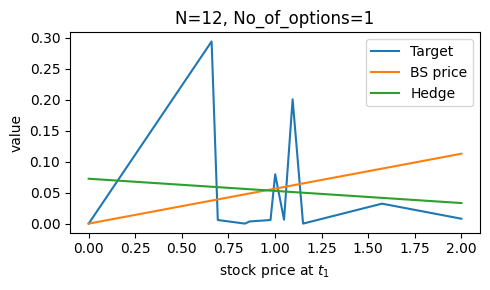

In [17]:
#PLOT AND CHECK HOW IT LOOKS

Weights_opt_without_bounds = result_with_L2["w_opt"]
P_matrix_no_bounds = result_with_L2["p_matrix"]

plot_one_run( K1,
    K2,
    truncation_range,
    N,
    Weights_opt_without_bounds,
    P_matrix_no_bounds,
    marg,
    K,
    T_GRID,
    sigma,
    r,
    run_idx=None,
    short_strikes=short_strikes,
    save=False,
    fname='Conditional_plot_no_bounds_zoomed_in',
    show=True,
    asian_payoff=Asian_option_payoff,
    bs_call=BS_call,
    
)
    


In [18]:
def solve_max_problem_gurobi(M_bound,
    K1, K2,
    Weights_min_prev, short_strikes, target_strike,
    marg, Epsilon
):
    """
    A version of the 'solve_max_problem_gurobi' function that uses row-specific M_i
    instead of one global M_bound.
    """
    # Create a Gurobi model
    model = gp.Model("Upper-Bound-Problem-RowSpecificM")
    model.setParam('OutputFlag', 0)

    N = len(K1)
    no_of_options = len(short_strikes)

    # Decision variables
    X = model.addVars(N, N, lb=0, ub=1, vtype=GRB.CONTINUOUS, name="X")
    P_slack = model.addVars(N, lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name="P_slack")
    B = model.addVars(N, vtype=GRB.BINARY, name="B")
#     Delta = model.addVars(N, lb=0, vtype=GRB.CONTINUOUS, name="Delta")

    # Objective: Maximize sum of P_slack
    model.setObjective(quicksum(P_slack[i] for i in range(N)), GRB.MAXIMIZE)

    
  

    
     
    for i in range(N):
         # The hedging_error expression
        hedging_error = (quicksum(X[i, j] * Asian_option_payoff(K1[i],K2[j],target_strike) for j in range(N)) \
                        - marg[0][i] * (
                            Weights_min_prev[0]
                            + quicksum(
                                Weights_min_prev[l+1] * max(K1[i] - short_strikes[l], 0)
                                for l in range(no_of_options)
                            )
                           )
                        )
        # -- Absolute value constraints:
        # a) hedging_error <= P_slack[i]
        model.addConstr(hedging_error <= P_slack[i], f"modulus_1_{i}")

        # b) hedging_error >= -P_slack[i]
        model.addConstr(hedging_error >= -P_slack[i], f"modulus_2_{i}")

#         # d) hedging_error *(1 - 2*B[i]) == P_slack[i]
        
        if M_bound is not None:
            #         # Modulus Constraint 3 (Big-M)

            model.addConstr( hedging_error + M_bound * B[i] >= P_slack[i],name=f"modulus_constraint_3_{i}")


            # Modulus Constraint 4 (Big-M)

            model.addConstr( -hedging_error + M_bound * (1 - B[i]) >= P_slack[i],name=f"modulus_constraint_4_{i}")

        else:
            # d) hedging_error *(1 - 2*B[i]) == P_slack[i]
            model.addConstr(hedging_error *(1 - 2*B[i]) == P_slack[i], f"modulus_3_{i}")
        
    
    
#     # Sign[i] == 1  ->  e_i >= 0  &  P ==  e_i
#         model.addGenConstrIndicator(B[i], True,  hedging_error, GRB.GREATER_EQUAL, 0.0)
#         model.addGenConstrIndicator(B[i], True,  hedging_error - P_slack[i], GRB.EQUAL, 0.0)

#         # Sign[i] == 0  ->  e_i <= 0  &  P == -e_i
#         model.addGenConstrIndicator(B[i], False, hedging_error, GRB.LESS_EQUAL,   0.0)
#         model.addGenConstrIndicator(B[i], False, P_slack[i] + hedging_error , GRB.EQUAL, 0.0)
   
    # Marginal constraints
    for i in range(N):
        model.addConstr(quicksum(X[i, j] for j in range(N)) == marg[0][i], f"time1_{i}")

    for j in range(N):
        model.addConstr(quicksum(X[i, j] for i in range(N)) == marg[1][j], f"time2_{j}")

    # Martingale constraints 
   
    for i in range(N):
        model.addConstr(quicksum(X[i, j]*(K2[j] - K1[i]) for j in range(N)) == 0, f"martingale_{i}")
    
#     model.setParam('NonConvex', 2)

    # Solve the model
    model.optimize()

    if model.status != GRB.OPTIMAL:
        return {
            "call_value": float("inf"),
            "Status": model.status,
            "p_matrix": None,
            "P_slack": None,
            "B": None,
#             "Delta": None
        }
    
 
    # 6) Extract solution
    p_matrix = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            p_matrix[i, j] = X[i, j].X

    p_slack_array = np.array([P_slack[i].X for i in range(N)])
    b_array       = np.array([B[i].X          for i in range(N)])
#     delta_array   = np.array([Delta[i].X      for i in range(N)])
    call_value    = model.objVal
    
    print(call_value)
    return {
        "call_value": call_value,
        "Status": "Optimal",
        "p_matrix": p_matrix,
        "P_slack": p_slack_array,
        "B": b_array,
#         "Delta": delta_array,
       
    }


In [19]:
result_max =solve_max_problem_gurobi(10,
    K1, K2,
    result_with_L2["w_opt"], short_strikes, K,
    marg, 0
)
print(f"objective value:{result_max['call_value']}")
      

0.059571978843159824
objective value:0.059571978843159824


In [20]:
#solving the maximization problem by splitting hedging error into positive and negative parts

def solve_max_problem_gurobi_with_pos_negative(
    K1, K2,
    Weights_min_prev, short_strikes, target_strike,
    marg):
    """
    Solves the hedging problem using positive/negative variable splitting
    instead of big-M constraints for absolute values.
    """
    # Create a Gurobi model
    model = gp.Model("Upper-Bound-Problem-PosNegSplit")
#     model.setParam('OutputFlag', 0)

    N1,N2 = len(K1),len(K2)
    no_of_options = len(short_strikes)

    # Decision variables
    X = model.addVars(N1, N2, lb=0, ub=1, vtype=GRB.CONTINUOUS, name="X")
    
#     # Split P_slack into positive and negative parts (P_slack = P_pos + P_neg)
#     P_pos = model.addVars(N, lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name="P_pos")
#     P_neg = model.addVars(N, lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name="P_neg")
    
    # Split hedging error into positive and negative parts
    hedging_pos = model.addVars(N1, lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name="hedging_pos")
    hedging_neg = model.addVars(N1, lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name="hedging_neg")

    # Objective: Maximize sum of P_slack (which is P_pos + P_neg)
    model.setObjective(quicksum(hedging_pos[i] + hedging_neg[i] for i in range(N1)), GRB.MAXIMIZE)

    for i in range(N1):
        # The hedging_error expression (split into positive and negative parts)
        hedging_error_expr = (quicksum(X[i, j] * Asian_option_payoff(K1[i], K2[j], target_strike) for j in range(N2)) \
                           - marg[0][i] * (
                               Weights_min_prev[0]
                               + quicksum(
                                   Weights_min_prev[l+1] * max(K1[i] - short_strikes[l], 0)
                                   for l in range(no_of_options)
                               )
                           )
                             )
       
        # Decompose hedging error into positive and negative parts
        model.addConstr(hedging_error_expr == hedging_pos[i] - hedging_neg[i], f"hedging_error_split_{i}")
        
#         # Connect to P_slack (absolute value)
#         model.addConstr(P_pos[i] + P_neg[i] >= hedging_pos[i] + hedging_neg[i], f"abs_value_{i}")
        
        # Optional: Add complementarity constraints
        model.addConstr(hedging_pos[i] * hedging_neg[i] == 0, f"complementarity_{i}")

    # Marginal constraints
    for i in range(N1):
        model.addConstr(quicksum(X[i, j] for j in range(N2)) == marg[0][i], f"time1_{i}")

    for j in range(N2):
        model.addConstr(quicksum(X[i, j] for i in range(N1)) == marg[1][j], f"time2_{j}")

    # Martingale constraints
    for i in range(N1):
        model.addConstr(quicksum(X[i, j]*(K2[j] - K1[i]) for j in range(N2)) == 0, f"martingale_{i}")

    # Solve the model
    model.optimize()

    if model.status != GRB.OPTIMAL:
        return {
            "call_value": float("inf"),
            "Status": model.status,
            "p_matrix": None,
#             "P_slack": None,
            "hedging_error": None
        }
    
    # Extract solution
    p_matrix = np.zeros((N1, N2))
    for i in range(N1):
        for j in range(N2):
            p_matrix[i, j] = X[i, j].X

#     p_slack_array = np.array([P_pos[i].X + P_neg[i].X for i in range(N)])
    hedging_error_array = np.array([hedging_pos[i].X - hedging_neg[i].X for i in range(N1)])
   
    hedging_error = sum(np.abs(element) for element in hedging_error_array)
    return {
        "call_value": model.objVal,
        "Status": "Optimal",
        "p_matrix": p_matrix,
#         "P_slack": p_slack_array,
        "hedging_error": hedging_error
    }

In [21]:
solve_max_problem_gurobi_with_pos_negative(
    K1, K2,
    result_with_L2["w_opt"], short_strikes, K,
    marg
)

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "Ubuntu 22.04.3 LTS")

CPU model: Intel(R) Xeon(R) Gold 6138 CPU @ 2.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 40 physical cores, 80 logical processors, using up to 32 threads

Optimize a model with 48 rows, 168 columns and 512 nonzeros
Model fingerprint: 0xa6d9dbe9
Model has 12 quadratic constraints
Coefficient statistics:
  Matrix range     [8e-03, 2e+00]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e-06, 2e-01]
Presolve removed 4 rows and 3 columns

Continuous model is non-convex -- solving as a MIP

Presolve removed 5 rows and 16 columns
Presolve time: 0.01s
Presolved: 43 rows, 152 columns, 460 nonzeros
Presolved model has 11 SOS constraint(s)
Variable types: 152 continuous, 0 integer (0 binary)

Root relaxation: unbounded, 0 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds    

{'call_value': 0.05957197884316095,
 'Status': 'Optimal',
 'p_matrix': array([[8.20130270e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 3.59184335e-03, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 4.05576663e-02, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 9.87190708e-02,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 3.3626879

**FORMULATE AS A SINGLE MAX PROBLEM **

In [22]:
###############################################################################
# maximise_LP_full.py
# ---------------------------------------------------------------------------
#  Implements and solves the LP:
#
#    max   Σ (-v_i) a_i + Σ v_i b_i
#    s.t.  Σ (-a_i+b_i)                = 0
#          Σ (-a_i+b_i) φ_{iℓ}         = 0      (ℓ = 1..m)
#          -a_i - b_i - p_i            ≤ 1      (∀ i)
#          a_i , b_i , p_i            ≥ 0
#          P_{ij} row/column/martingale constraints
#          v_i = Σ_j P_{ij} c_{ij}
#
#  Requires:  Gurobi + Python bindings
###############################################################################



# ---------------------------------------------------------------------------
#  Helper functions
# ---------------------------------------------------------------------------
def asian_payoff_matrix(K1, K2, strike):
    """c_{ij} = max(0.5 (K1_i + K2_j) - strike, 0)"""
    K1 = np.asarray(K1)[:, None]          # (N1, 1)
    K2 = np.asarray(K2)[None, :]          # (1,  N2)
    return np.maximum(0.5 * (K1 + K2) - strike, 0.0)


def build_phi(K1, strikes):
    """φ_{iℓ} = (K1_i - strike_ℓ)^+"""
    K1 = np.asarray(K1)
    strikes = np.asarray(strikes)
    return np.maximum(K1[:, None] - strikes[None, :], 0.0)   # (N1, m)


# ---------------------------------------------------------------------------
#  Main LP builder / solver
# ---------------------------------------------------------------------------
def solve_single_max_LP(
    K1, K2,               # strike grids (array-like)
    mu, nu,               # discrete marginals
    short_strikes,        # strikes that define φ
    asian_strike,         # strike of Asian payoff
    *,
    silent=True,
):
    K1 = np.asarray(K1, dtype=float)
    K2 = np.asarray(K2, dtype=float)
    mu = np.asarray(mu, dtype=float)
    nu = np.asarray(nu, dtype=float)

    N1, N2 = len(K1), len(K2)
    m = len(short_strikes)

    # φ and payoff matrices
    phi = build_phi(K1, short_strikes) # shape (N1, m)
    
    c = np.ones((N1,N2))
    
    for i in range(N1):
        for j in range(N2):
            c[i,j]   = Asian_option_payoff(K1[i], K2[j], asian_strike)  # shape (N1, N2)

    # ------------------ model ----------------------
    mdl = gp.Model("max_abs_dual_full")
    if silent:
        mdl.setParam("OutputFlag", 0)
    # memory / log
    mdl.setParam('NodefileStart', 0.5)
    mdl.setParam('NodefileDir', '/tmp')
    mdl.setParam('DisplayInterval', 60)

    # gap / time
    
    mdl.setParam('MIPGap', 1e-4)  # 0.01% relative gap
    mdl.setParam('FeasibilityTol', 1e-6)
    mdl.setParam('OptimalityTol', 1e-6)
    mdl.setParam('TimeLimit', 14400)    # 4 h hard stop
    
    
    # Dual variables (non-negative)
    a = mdl.addVars(N1, lb=0.0, name="a")
    b = mdl.addVars(N1, lb=0.0, name="b")
#     q = mdl.addVars(N1, ub=0.0, name="p")

    # Coupling vars  P_{ij} ≥ 0
    P = mdl.addVars(N1, N2, lb=0.0,ub=1.0, name="P")

    # v_i expressions
    v_expr = [
        gp.quicksum(P[i, j] * c[i, j]/max(mu[i],1e-10) for j in range(N2))
        for i in range(N1)
    ]

    # Objective
    mdl.setObjective(
        gp.quicksum((-v_expr[i]) * a[i] + v_expr[i] * b[i] for i in range(N1)),
        GRB.MAXIMIZE,
    )

    # Unrestricted-w equalities
    mdl.addConstr(gp.quicksum(-a[i] + b[i] for i in range(N1)) == 0.0,
                  name="w0_eq")
    
    for ell in range(m):
        mdl.addConstr(
            gp.quicksum((-a[i] + b[i]) * max(K1[i]- short_strikes[ell],0) for i in range(N1)) == 0.0,
            name=f"w{ell+1}_eq",
        )



    mdl.addConstrs(
        (a[i] + b[i] <= mu[i] for i in range(N1)),
        name="z_col",
    )

    # Coupling constraints
    mdl.addConstrs(
        (gp.quicksum(P[i, j] for j in range(N2)) == float(mu[i])
         for i in range(N1)),
        name="row_marg",
    )
    mdl.addConstrs(
        (gp.quicksum(P[i, j] for i in range(N1)) == float(nu[j])
         for j in range(N2)),
        name="col_marg",
    )
    mdl.addConstrs(
        (gp.quicksum(P[i, j] * (K2[j] - K1[i]) for j in range(N2))
         == 0
         for i in range(N1)),
        name="martingale",
    )
#     a_i + b_i ≤ 1   (for every i)
#     mdl.addConstrs(a[i] + b[i] <= 1.0   for i in range(N1))
    # Solve
    
    
    for i in range(N1):
        a[i].start = 0.0
        b[i].start = 0.0
    for i in range(N1):
        for j in range(N2):
            P[i,j].start = mu[i]*nu[j]
            
    mdl.optimize()
    if mdl.status != GRB.OPTIMAL:
        raise RuntimeError(f"Gurobi status {mdl.status}")

    # Extract solution
    a_opt = np.array([a[i].X for i in range(N1)])
    b_opt = np.array([b[i].X for i in range(N1)])

    P_opt = np.array([[P[i, j].X for j in range(N2)] for i in range(N1)])

    return {
        "objective": mdl.objVal,
        "a": a_opt,
        "b": b_opt,
#         "q": q_opt,
        "P": P_opt,
        "status": "optimal",
    }


# ---------------------------------------------------------------------------
#  Example run
# ---------------------------------------------------------------------------
# if __name__ == "__main__":
#     # toy 2×2 grid
   
#     sol = solve_single_max_LP(
#         K1, K2, marg[0], marg[1],
#         short_strikes,
#         K,
#         silent=False,
#     )

#     print("\n--- optimal values ---")
#     print("objective =", sol["objective"])
#     print("a* =", sol["a"])
#     print("b* =", sol["b"])
# #     print("q* =", sol["q"])
#     print("P* =\n", sol["P"])
    
    
#     P_matrix = sol["P"]

In [23]:
#FORMULATE THE INNER MNMIZATION LP IN STANDARD FORM USING POSITIVE AND NEGATIVE PARTS

# def solve_min_LP_2(
#     K1, K2,               # strike grids (array-like)
#     mu, nu,               # discrete marginals
#     short_strikes,        # strikes that define φ
#     asian_strike, 
#     P,# strike of Asian payoff
#     *,
#     silent=True,
# ):
#     K1 = np.asarray(K1, dtype=float)
#     K2 = np.asarray(K2, dtype=float)
#     mu = np.asarray(mu, dtype=float)
#     nu = np.asarray(nu, dtype=float)

#     N1, N2 = len(K1), len(K2)
#     m = len(short_strikes)

#     print(f"length of short strikes:{m}")
    
#     c = np.ones((N1,N2))
    
#     for i in range(N1):
#         for j in range(N2):
#             c[i,j]   = Asian_option_payoff(K1[i], K2[j], asian_strike)  # shape (N1, N2)

#     # ------------------ model ----------------------
#     mdl = gp.Model("min_abs_LP")
#     if silent:
#         mdl.setParam("OutputFlag", 0)

#     # Dual variables (non-negative)
    
#     Z = mdl.addVars(N1, lb=0.0, name="Z")
#     W_pos = mdl.addVars(m+1, lb=0, name="W_pos")
#     W_neg = mdl.addVars(m+1, lb=0, name="W_neg") 
# #     q = mdl.addVars(N1, ub=0.0, name="p")

#      # v_i expressions
#     v_expr = [
#         sum(P[i, j] * c[i, j]/mu[i] for j in range(N2))
#         for i in range(N1)
#     ]



#     # Objective
#     mdl.setObjective(gp.quicksum(mu[i] * Z[i] 
#         for i in range(N1)),
#         GRB.MINIMIZE,
#     )

    
#     for i in range(N1):
#         mdl.addConstr(Z[i] + (W_pos[0] - W_neg[0]) + gp.quicksum((W_pos[ell+1]  - W_neg[ell+1])* 
#                                                                  max(K1[i]-short_strikes[ell],0) for ell in range(m))
#                       >= v_expr[i]
#             )
        
        
#         mdl.addConstr(Z[i] - (W_pos[0] - W_neg[0])  - gp.quicksum((W_pos[ell+1]- W_neg[ell+1])* 
#                                                                  max(K1[i]-short_strikes[ell],0) for ell in range(m))
#                      >= -v_expr[i]
#                      )


    
# #     a_i + b_i ≤ 1   (for every i)
# #     mdl.addConstrs(a[i] + b[i] <= 1.0   for i in range(N1))
#     # Solve
#     mdl.optimize()
#     if mdl.status != GRB.OPTIMAL:
#         raise RuntimeError(f"Gurobi status {mdl.status}")

#     # Extract solution
#     Z_opt = np.array([Z[i].X for i in range(N1)])
#     W_opt = np.array([(W_pos[i].X - W_neg[i].X) for i in range(len(W_pos))])

#     return {
#         "objective": mdl.objVal,
#         "Z": Z_opt,
#         "W": W_opt,
#       "status": "optimal",
#     }


# # ---------------------------------------------------------------------------
# #  Example run
# # ---------------------------------------------------------------------------
# if __name__ == "__main__":
#     # toy 2×2 grid
   
#     sol_min_LP_with_pos_neg = solve_min_LP_2(
#         K1, K2, marg[0], marg[1],
#         short_strikes,
#         K,
#         P_matrix,
#         silent=False,
#     )

#     print("\n--- optimal values ---")
#     print("objective =", sol_min_LP_with_pos_neg["objective"])
#     print("Z =", sol_min_LP_with_pos_neg["Z"])
#     print("Weights =", sol_min_LP_with_pos_neg["W"])



In [24]:

# def solve_min_LP_dual(
#     K1, K2,               # strike grids (array-like)
#     mu, nu,               # discrete marginals
#     short_strikes,        # strikes that define φ
#     asian_strike,  
#     P,# strike of Asian payoff
#     *,
#     silent=True,
# ):
#     K1 = np.asarray(K1, dtype=float)
#     K2 = np.asarray(K2, dtype=float)
#     mu = np.asarray(mu, dtype=float)
#     nu = np.asarray(nu, dtype=float)

#     N1, N2 = len(K1), len(K2)
#     m = len(short_strikes)

    
#     c = np.ones((N1,N2))
    
#     for i in range(N1):
#         for j in range(N2):
#             c[i,j]   = Asian_option_payoff(K1[i], K2[j], asian_strike)  # shape (N1, N2)

#     # ------------------ model ----------------------
#     mdl = gp.Model("max_abs_dual_full")
#     if silent:
#         mdl.setParam("OutputFlag", 0)

#     # Dual variables (non-negative)
#     a = mdl.addVars(N1, lb=0.0, name="a")
#     b = mdl.addVars(N1, lb=0.0, name="b")
# #     q = mdl.addVars(N1, ub=0.0, name="p")

    
#     # v_i expressions
#     v_expr = [
#         gp.quicksum(P[i, j] * c[i, j]/mu[i] for j in range(N2))
#         for i in range(N1)
#     ]

#     # Objective
#     mdl.setObjective(
#         gp.quicksum((-v_expr[i]) * a[i] + v_expr[i] * b[i] for i in range(N1)),
#         GRB.MAXIMIZE,
#     )

#     # Unrestricted-w equalities
#     mdl.addConstr(gp.quicksum(-a[i] + b[i] for i in range(N1)) == 0.0,
#                   name="w0_eq")
#     for ell in range(m):
#         mdl.addConstr(
#             gp.quicksum((-a[i] + b[i]) * max(K1[i]- short_strikes[ell],0) for i in range(N1)) == 0.0,
#             name=f"w{ell+1}_eq",
#         )

# #     #  -a_i - b_i - p_i ≤ 1
# #     mdl.addConstrs(
# #         (-a[i] - b[i] <= mu[i] for i in range(N1)),
# #         name="z_col",
# #     )

#     mdl.addConstrs(
#         (a[i] + b[i] <= mu[i] for i in range(N1)),
#         name="z_col",
#         )

  
# #     a_i + b_i ≤ 1   (for every i)
# #     mdl.addConstrs(a[i] + b[i] <= 1.0   for i in range(N1))
#     # Solve
#     mdl.optimize()
#     if mdl.status != GRB.OPTIMAL:
#         raise RuntimeError(f"Gurobi status {mdl.status}")

#     # Extract solution
#     a_opt = np.array([a[i].X for i in range(N1)])
#     b_opt = np.array([b[i].X for i in range(N1)])


#     return {
#         "objective": mdl.objVal,
#         "a": a_opt,
#         "b": b_opt,
# #   
#         "status": "optimal",
#     }


# # ---------------------------------------------------------------------------
# #  Example run
# # ---------------------------------------------------------------------------
# if __name__ == "__main__":
#     # toy 2×2 grid
   
#     sol_min_dual = solve_min_LP_dual(
#         K1, K2, marg[0], marg[1],
#         short_strikes,
#         K,
#         P_matrix,
#         silent=False,
#     )

#     print("\n--- optimal values ---")
#     print("objective =", sol_min_dual["objective"])
#     print("a* =", sol_min_dual["a"])
#     print("b* =", sol_min_dual["b"])
# #     print("q* =", sol["q"])
    
    
   

In [25]:

def solve_min_LP_dual(
    K1, K2,               # strike grids (array-like)
    mu, nu,               # discrete marginals
    short_strikes,        # strikes that define φ
    asian_strike,  
    P,# strike of Asian payoff
    *,
    silent=True,
):
    K1 = np.asarray(K1, dtype=float)
    K2 = np.asarray(K2, dtype=float)
    mu = np.asarray(mu, dtype=float)
    nu = np.asarray(nu, dtype=float)

    N1, N2 = len(K1), len(K2)
    m = len(short_strikes)

    
    c = np.ones((N1,N2))
    
    for i in range(N1):
        for j in range(N2):
            c[i,j]   = Asian_option_payoff(K1[i], K2[j], asian_strike)  # shape (N1, N2)

    # ------------------ model ----------------------
    mdl = gp.Model("max_abs_dual_full")
    if silent:
        mdl.setParam("OutputFlag", 0)

    # Dual variables (non-negative)
    a = mdl.addVars(N1, lb=0.0, name="a")
    b = mdl.addVars(N1, lb=0.0, name="b")
#     q = mdl.addVars(N1, ub=0.0, name="p")

    
    # v_i expressions
    v_expr = [
        gp.quicksum(P[i, j] * c[i, j]/mu[i] for j in range(N2))
        for i in range(N1)
    ]

    # Objective
    mdl.setObjective(
        gp.quicksum(v_expr[i] * a[i] - v_expr[i] * b[i] for i in range(N1)),
        GRB.MAXIMIZE,
    )

    # Unrestricted-w equalities
    mdl.addConstr(gp.quicksum(-a[i] + b[i] for i in range(N1)) == 0.0,
                  name="w0_eq")
    
    
    
    for ell in range(m):
        mdl.addConstr(
            gp.quicksum((-a[i] + b[i]) * max(K1[i]- short_strikes[ell],0) for i in range(N1)) == 0.0,
            name=f"w{ell+1}_eq",
        )
       


    mdl.addConstrs(
        (a[i] + b[i] <= mu[i] for i in range(N1)),
        name="z_col",
        )

  

    # Solve
    mdl.optimize()
    if mdl.status != GRB.OPTIMAL:
        raise RuntimeError(f"Gurobi status {mdl.status}")

    # Extract solution
    a_opt = np.array([a[i].X for i in range(N1)])
    b_opt = np.array([b[i].X for i in range(N1)])


    return {
        "objective": mdl.objVal,
        "a": a_opt,
        "b": b_opt,
#   
        "status": "optimal",
    }


# ---------------------------------------------------------------------------
#  Example run
# ---------------------------------------------------------------------------
# if __name__ == "__main__":
#     # toy 2×2 grid
   
#     sol_min_dual = solve_min_LP_dual(
#         K1, K2, marg[0], marg[1],
#         short_strikes,
#         K,
#         P_matrix,
#         silent=False,
#     )

#     print("\n--- optimal values ---")
#     print("objective =", sol_min_dual["objective"])
#     print("a* =", sol_min_dual["a"])
#     print("b* =", sol_min_dual["b"])
# #     print("q* =", sol["q"])
    
    
   

In [26]:
def solve_min_LP(
    K1, K2,               # strike grids (array-like)
    mu, nu,               # discrete marginals
    short_strikes,        # strikes that define φ
    asian_strike, 
    P,# strike of Asian payoff
    *,
    silent=True,
):
    K1 = np.asarray(K1, dtype=float)
    K2 = np.asarray(K2, dtype=float)
    mu = np.asarray(mu, dtype=float)
    nu = np.asarray(nu, dtype=float)

    N1, N2 = len(K1), len(K2)
    m = len(short_strikes)

#     print(f"length of short strikes:{m}")
    
    c = np.ones((N1,N2))
    
    for i in range(N1):
        for j in range(N2):
            c[i,j]   = Asian_option_payoff(K1[i], K2[j], asian_strike)  # shape (N1, N2)

    # ------------------ model ----------------------
    mdl = gp.Model("min_abs_LP")
    if silent:
        mdl.setParam("OutputFlag", 0)

    # Dual variables (non-negative)
    
    Z = mdl.addVars(N1, lb=0.0, name="Z")
    W = mdl.addVars(m+1, lb=-GRB.INFINITY, ub = GRB.INFINITY, name="W")
#     q = mdl.addVars(N1, ub=0.0, name="p")

     # v_i expressions
    v_expr = [
        sum(P[i, j] * c[i, j] for j in range(N2))
        for i in range(N1)
    ]



    # Objective
    mdl.setObjective(gp.quicksum( Z[i] 
        for i in range(N1)),
        GRB.MINIMIZE,
    )

    
    for i in range(N1):
        mdl.addConstr(v_expr[i] - mu[i]*(W[0] + gp.quicksum(W[ell+1] * max(K1[i]-short_strikes[ell],0) 
                                                            for ell in range(m)))
                      <= Z[i]
            )
        
        
        mdl.addConstr(-v_expr[i] + mu[i]*(W[0] + gp.quicksum(W[ell+1] * max(K1[i]-short_strikes[ell],0) 
                                                             for ell in range(m))
                                         ) <= Z[i]
                     )

    
    
#     a_i + b_i ≤ 1   (for every i)
#     mdl.addConstrs(a[i] + b[i] <= 1.0   for i in range(N1))
    # Solve
    mdl.optimize()
    
   
    if mdl.status != GRB.OPTIMAL:
        raise RuntimeError(f"Gurobi status {mdl.status}")

    # Extract solution
    Z_opt = np.array([Z[i].X for i in range(N1)])
    W_opt = np.array([W[i].X for i in range(len(W))])

    residual = np.max([abs(v_expr[i] -
                       (W_opt[0] + sum(W_opt[ell+1]*max(K1[i]-short_strikes[ell],0)
                                      for ell in range(m))))
                   for i in range(N1)])
#     print("   max |v-g_w| :", residual)
    
    return {
        "objective": mdl.objVal,
        "Z": Z_opt,
        "W": W_opt,
      "status": "optimal",
    }


# ---------------------------------------------------------------------------
#  Example run
# ---------------------------------------------------------------------------
# if __name__ == "__main__":
#     # toy 2×2 grid
   
#     sol_min_LP = solve_min_LP(
#         K1, K2, marg[0], marg[1],
#         short_strikes,
#         K,
#         P_matrix,
#         silent=False,
#     )

#     print("\n--- optimal values ---")
#     print("objective =", sol_min_LP["objective"])
#     print("Z =", sol_min_LP["Z"])
#     print("Weights =", sol_min_LP["W"])

# plot_one_run( K1,
#     K2,
#     truncation_range,
#     N,
#     sol_min_LP["W"],
#     P_matrix,
#     marg,
#     K,
#     T_GRID,
#     sigma,
#     r,
#     short_strikes,
#     run_idx=None,
#     save=False,
#     fname='Conditional_plot_no_bounds_zoomed_in',
#     show=True,
#     asian_payoff=Asian_option_payoff,
#     bs_call=BS_call,
#              lo=2,
#              hi=-2
   
# )
    

In [45]:

def max_min_optimization(solve_min_problem,
    K1,
    K2,
    short_strikes,
    no_of_options,
    target_strike,
    marg,
    short_call,
    x0, #initial choice for probabilities
    seed,
    bounds,
):
    """
    Returns the result of the min-max process for a given number of options
    in the hedge portfolio.
    """

    # Keep a log of intermediate values
    log = []

    n_timepoint_1 = len(marg[0])
    n_timepoint_2 = len(marg[1])
    
    
    mu = marg[0]
    nu = marg[1]
    
    

    def vector_to_matrix(x):
        #convert the vector into a matrix
        return x.reshape(n_timepoint_1,n_timepoint_2)
    
    
    def max_function_on_probabilities(p_flat):
        """
        Inner objective: given a set of hedge weights, solve the max problem
        and compute the "error" (sum of absolute differences).
        """
        p_matrix = vector_to_matrix(p_flat)
        
#         print("P_matrix",p_matrix.shape)
        # Solve the inner min problem
        result = solve_min_problem( 
            K1, K2,               # strike grids (array-like)
            mu, nu,               # discrete marginals
            short_strikes,        # strikes that define φ
            target_strike,  
            p_matrix
        )
       
        Status = result["status"]
        if Status != "optimal":
            # If infeasible or not optimal, penalize heavily
            print(f"Warning: Status is {Status}, no solution found.")
            return float("inf")
       
        Weights_with_cash = result["W"]
#         print("Weights:",Weights_with_cash)
        #objective value
        function_in_p = result["objective"]
     

        
#         #compute the optimal cash position 
        cash =  Weights_with_cash[0] 
        Weights_of_options = Weights_with_cash[1:] 
        
        #compute the objective value and hedge value
        hedge_value = 0
        for i in range(n_timepoint_1):
            payoff_target = sum(
                p_matrix[i,j] * Asian_option_payoff(K1[i],K2[j],target_strike) 
                for j in range(n_timepoint_2))
            

            payoff_hedge = mu[i] * (cash
                + sum(
                    Weights_of_options[l] * max(K1[i] - short_strikes[l], 0)
                    for l in range(no_of_options)
                )
            )
            
            hedge_value += payoff_hedge
        
        
        #compute the target option price
        target_price = 0
        for i in range(n_timepoint_1):
            for j in range(n_timepoint_2):
                target_price +=  p_matrix[i,j] * Asian_option_payoff(K1[i],K2[j],K)
        
       
        

        
        # Record everything in our log
        log_entry = {
            "Weights": Weights_with_cash,
            "Objective value (outer)": function_in_p,
            "p_matrix": p_matrix,
            "Status": Status,
            "target_price": target_price,
            "hedge_value": hedge_value
        }
        log.append(log_entry)
        
        print(f"val solving inner min LP:{function_in_p}\n")
       
        return -function_in_p
    
    
      # constraints 
    row_constraints = [
        {'type': 'eq',
         'fun' : (lambda x, idx=i:
                  vector_to_matrix(x)[idx, :].sum() - mu[idx])}
        for i in range(n_timepoint_1)
    ]

    column_constraints = [
        {'type': 'eq',
         'fun' : (lambda x, jdx=j:
                  vector_to_matrix(x)[:, jdx].sum() - nu[jdx])}
        for j in range(n_timepoint_2)
    ]

    martingale_constraints = [
        {'type': 'eq',
         'fun' : (lambda x, idx=i:
                  np.dot(vector_to_matrix(x)[idx, :], K2 - K1[idx]))}
        for i in range(n_timepoint_1)
    ]

    constraints = row_constraints + column_constraints + martingale_constraints

   
    
#     row_constraints =  [{'type':'eq',
#                   'fun': (lambda x, idx=i: np.sum(vector_to_matrix(x)[idx,:])-mu[idx])
#                         }
                        
#                         for i in range(n_timepoint_1)] 
    
#     test_x = x0.copy()
#     print(row_constraints[0]['fun'](test_x))
    
#     column_constraints =  [{'type':'eq',
#                   'fun':( lambda x, idx=j: np.sum(vector_to_matrix(x)[:,idx])-nu[idx])
                           
#                            }
#                            for j in range(n_timepoint_2)] 
   
#     martingale_constraints =  [{'type':'eq',
#                   'fun':( lambda x, idx=i: np.dot(vector_to_matrix(x)[idx,:],K2[:]-K1[idx]))
                           
#                            }
#                            for i in range(n_timepoint_1)] 
    
    
    
#     constr =  row_constraints + column_constraints +  martingale_constraints
    
    n_vars  = n_timepoint_1 * n_timepoint_2
    if x0 is None:
        x0 = np.full(n_vars, 1.0 / n_vars)
    bounds  = [(0.0, 1.0)] * n_vars 
    
    
    def debug_cb(x):
        P = vector_to_matrix(x)
        row_res = np.max(np.abs(P.sum(axis=1) - mu))
        col_res = np.max(np.abs(P.sum(axis=0) - nu))
        mart_res= np.max(np.abs(np.dot(P, K2) - mu * K1))
#         print(f"row_res={row_res:.2e} col_res={col_res:.2e} mart_res={mart_res:.2e}")

    result_min = minimize(fun=max_function_on_probabilities,bounds= bounds,
                                 x0=x0,
                                 method='SLSQP',
                                constraints=constraints,

                                callback= debug_cb,
                                   options={'ftol':1e-15,
                                            'eps':1e-15,
                                            'maxiter':50000,
                                            'disp':True}
#                                       options=dict(maxiter=10000*(no_of_options+1),
#                                                    maxfev=10000*(no_of_options+1),fatol= 1e-8, xatol= 1e-6,
#                                                    disp=True)
                                                   
                                    )
    

    if result_min.success:
        p_matrix_opt = vector_to_matrix(result_min.x)
        final_value = -result_min.fun
        print(result_min.message)
        return p_matrix_opt, final_value, log
    else:
        print("Simulated annealing failed")
        return None, float("inf"), log


In [28]:
def check_constraints_pulp_solution_no_M(
    K1, K2,
    p_matrix,
    Weights,         # [cash, w1, w2, ...]
    short_strikes,
    target_strike,
    marg,
    tolerance=1e-8
):
    """
    Re-checks constraints from solve_max_problem_gurobi_without_M.
    Returns (all_satisfied, violations).
    """

    # ============= 1) Basic Setup =============
    n_timepoint_1 = len(marg[0])  # alpha
    n_timepoint_2 = len(marg[1])  # beta
    no_of_options = len(short_strikes)

    
    violations = []

    # ============= 2) Timepoint 1 Constraints =============
    # sum_j p[i,j] == marg[0][i]
    for i in range(n_timepoint_1):
        lhs = np.sum(p_matrix[i,:])
        rhs = marg[0][i]
        if abs(lhs - rhs) > tolerance:
            msg = f"Row sum constraint violated at i={i}: LHS={lhs}, RHS={rhs}"
            violations.append(msg)

    # ============= 3) Timepoint 2 Constraints =============
    # sum_i p[i,j] == marg[1][j]
    for j in range(n_timepoint_2):
        lhs = np.sum(p_matrix[:, j])
        rhs = marg[1][j]
        if abs(lhs - rhs) > tolerance:
            msg = f"Column sum constraint violated at j={j}: LHS={lhs}, RHS={rhs}"
            violations.append(msg)

    # ============= 4) Martingale Constraints =============
    # sum_j p[i,j]*(K2[j] - K1[i]) = 0  for each i
    for i in range(n_timepoint_1):
        lhs = 0.0
        for j in range(n_timepoint_2):
            lhs += p_matrix[i, j]*(K2[j] - K1[i])
        if abs(lhs) > tolerance:
            msg = f"Martingale constraint violated at i={i}: LHS={lhs}"
            violations.append(msg)

   
    alpha = marg[0]
    cash  = Weights[0]
    w_opts = Weights[1:]  # the short positions
  

    for i in range(n_timepoint_1):
        # payoff_target
        payoff_target = 0.0
        for j in range(n_timepoint_2):
            payoff_target += p_matrix[i,j] * Asian_option_payoff(K1[i], K2[j], target_strike) 

        # payoff_hedge
        payoff_hedge = alpha[i]*(
            cash + sum(
                w_opts[l] * max(K1[i] - short_strikes[l], 0)
                for l in range(no_of_options)
            )
        )

        hedging_error = payoff_target - payoff_hedge

        
      

    # ============= Finalize =============
    all_satisfied = (len(violations) == 0)
    return (all_satisfied, violations)


In [29]:
###############################################################################
#  MAIN DRIVER (run_experiment) 
###############################################################################
def run_max_min_experiment(
    truncation_range=None,
    n=None,
    N=None,
    no_of_options=None,
    short_strikes=None,
    target_strike = None,
    choice=None,
    x0=None,
    seed=136, 
    bounds=None,                 
):
    """
    Orchestrates everything:
     1) Build discretization points & marginals
     2) Pick short strikes
     3) Compute target call & short calls
     4) Solve min-max
     5) Return final results
    """
    # Build grid & marginals
    disc_points_new, call_prices_array_new, marg = get_disc_points_and_marginals( truncation_range=truncation_range,\
                                                                                n=n,N=N,choice=choice)
    

    K1 = disc_points_new[0]
    
    K2 = disc_points_new[1]
   
    # Pick short strikes
    
#     print(f"Short strikes: {short_strikes}")

    # Compute  short calls

    short_call = get_short_call(T_GRID, T_GRID[1], no_of_options, marg, disc_points_new, short_strikes)
    print(f"length of short_call {len(short_call)}")

    mu = marg[0]
    nu = marg[1]
     
  
    solve_min_problem = solve_min_LP 

  
    # solve the min_max
    p_opt, final_value, log_results = max_min_optimization(solve_min_problem,
        K1,
        K2,
        short_strikes,
        no_of_options,
        target_strike,
        marg,
        short_call,
        x0,
        seed,
        bounds,
        
    )
    
    if p_opt is None:
        # pick the log entry with the largest objective value
        best = max(log_results, key=lambda d: d["Objective value (outer)"])
        p_opt       = best["p_matrix"]
        final_value = best["Objective value (outer)"]
        print("Using best point from log; optimiser did not converge.")
        
        
    
    #convert the value to maximization 
    final_value = - final_value
    
    # Solve the min problem once more with final_probability_matrix
    final_solution = solve_min_problem(
        K1,
        K2,
        mu,
        nu,
        short_strikes,
        K,
        p_opt
    )
    
 

    # Re-compute the target_call
   
    w_opt = final_solution["W"]
    target_call = 0
    n_timepoint_1 = len(K1)
    n_timepoint_2 = len(K2)
    
    for i in range(n_timepoint_1):
        for j in range(n_timepoint_2):
            target_call += p_opt[i][j] * Asian_option_payoff(K1[i],K2[j],target_strike)
    
    hedge_value = w_opt[0] + np.dot(w_opt[1:],short_call)

    # 8) Check constraints using the existing check_constraints_pulp_solution function
   
    if final_solution["status"].lower() =="optimal" and final_solution["W"] is not None:
        all_satisfied, violations = check_constraints_pulp_solution_no_M(
            K1, K2,
            p_opt,
            w_opt,
            short_strikes,
            K,
            marg,
             )

        if all_satisfied:
            print("All constraints are satisfied at the final solution!")
        else:
            print("Constraint violations found at the final solution:")
            for v in violations:
                print("  -", v)
    else:
        print("Final solution wasn't optimal, so skipping constraint check.")

   # after SLSQP terminates
    P = p_opt
    row_err = np.max(np.abs(P.sum(axis=1) - mu))
    col_err = np.max(np.abs(P.sum(axis=0) - nu))
    mart_err= np.max(np.abs(np.dot(P, K2) - mu*K1))
    print("max row residual =", row_err)
    print("max col residual =", col_err)
    print("max mart residual=", mart_err)

    # 9) Return final results
    return {
        "w_opt": w_opt,
        "final_value": final_value,
        "log": log_results,
        "N_initial": N, #initial choice of discretization points
        "N": len(K1),#total number of discretization points after interpolation 
        "value_from_min" : final_solution["objective"],
        "p_matrix": p_opt,
        "target_call_price": target_call,
        "hedge_value": hedge_value
    }

In [30]:
#Initial choice for the p_matrix

mat_product =marg[0][:,None]*marg[1][None,:]
[sum(mat_product[i,:]) for i in range(N)]

[np.float64(8.2013026976524e-05),
 np.float64(0.0035918433534676266),
 np.float64(0.04055766625252854),
 np.float64(0.09871907079414732),
 np.float64(0.1625500656852631),
 np.float64(0.18998185370376008),
 np.float64(0.10009758351795787),
 np.float64(0.11552757549669139),
 np.float64(0.10033502382784787),
 np.float64(0.15840301238001803),
 np.float64(0.03007986642323015),
 np.float64(7.442553811149157e-05)]

In [31]:
import gc
import psutil



Weights_opt_list = []
Objective_value_list = []
p_matrix_list = []
result_dict_list = []    

for n_op in range(1,N+1):
    no_of_options = n_op
    short_strikes = short_strike_range[:no_of_options]
    
    print(f"\n=====Experiment for number of options:{no_of_options}======\n")
    
    result_max_min = run_max_min_experiment(
        truncation_range=truncation_range,
        N=N,
        no_of_options=no_of_options,
        short_strikes=short_strikes,
        target_strike= K,
        choice="non-uniform",
        x0 = mat_product.ravel().tolist()
    )
    print(f"\n Optimal weights:{result_max_min['w_opt']}\n")
    
    print(f"Objective value:{result_max_min['final_value']}\n")
    
    gc.collect()  
    
    print(f"Used: {psutil.virtual_memory().used/1e9:.2f} GB")
    print(f"Free: {psutil.virtual_memory().free/1e9:.2f} GB")
    
    Weights_opt_list.append(result_max_min['w_opt'])
    Objective_value_list.append(result_max_min['final_value'])
    p_matrix_list.append(result_max_min['p_matrix'])
    result_dict_list.append(result_max_min)


=====Experiment for number of options:1======

The strike for time 0.5 is 2.0002422164631994 and interpolated call value: -5.4263048183478615e-21
The strike for time 1 is 2.0081747254138964 and interpolated call value: -1.6601845766184287e-19
The new discretization points are:[[0.         0.65985287 0.69305573 0.83860362 0.86371482 0.97595447
  1.00102542 1.0484879  1.09459717 1.15062857 1.57436388 2.00024222]
 [0.         0.65985287 0.69305573 0.83860362 0.86371482 0.97595447
  1.00102542 1.0484879  1.09459717 1.15062857 1.57436388 2.00817473]]
Number of discretization points are:12
timepoint: 0.5
12
Sum of marginals at 0.5 is: 1.0
timepoint: 1
12
Sum of marginals at 1 is: 1.0
Short call value 0 is: 1.0
length of short_call 1
Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.030814768093567615
            Iterations: 818
            Function evaluations: 123163
            Gradient evaluations: 817
Optimization terminated successfully
All co

Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.02234900821982918
            Iterations: 442
            Function evaluations: 66112
            Gradient evaluations: 442
Optimization terminated successfully
All constraints are satisfied at the final solution!
max row residual = 8.351067233569598e-17
max col residual = 8.326672684688674e-17
max mart residual= 8.794226832542714e-17

 Optimal weights:[ 0.00000000e+00  1.56949294e-09  6.10400999e-01 -6.60901439e-01
 -3.63081220e-02  9.29790245e-02  1.44435884e+00 -1.76955059e+00]

Objective value:-0.02234900821982918

Used: 12.80 GB
Free: 96.13 GB

=====Experiment for number of options:8======

The strike for time 0.5 is 2.0002422164631994 and interpolated call value: -5.4263048183478615e-21
The strike for time 1 is 2.0081747254138964 and interpolated call value: -1.6601845766184287e-19
The new discretization points are:[[0.         0.65985287 0.69305573 0.83860362 0.86371482 0.97595447
  1.00

Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.0
            Iterations: 5
            Function evaluations: 726
            Gradient evaluations: 5
Optimization terminated successfully
All constraints are satisfied at the final solution!
max row residual = 2.7755575615628914e-17
max col residual = 2.7755575615628914e-17
max mart residual= 5.551115123125783e-17

 Optimal weights:[ 0.00000000e+00  2.31160688e-04  1.31093822e+00 -1.32003099e+00
  3.27139110e-01 -2.75976978e-01 -3.21296824e-01  1.66146347e-01
  7.72247501e-01 -6.11587157e-01 -1.50814846e-01  4.56271868e-02
  0.00000000e+00]

Objective value:-0.0

Used: 13.22 GB
Free: 95.71 GB



===Plot for 1 options==


 Short strikes:[0.]



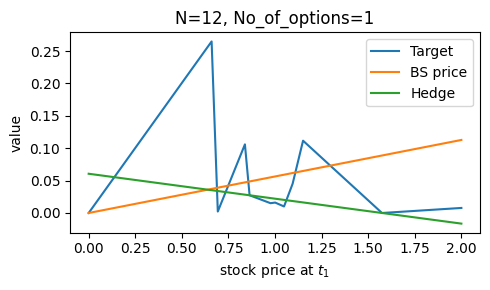


===Plot for 2 options==


 Short strikes:[0.         0.65985287]



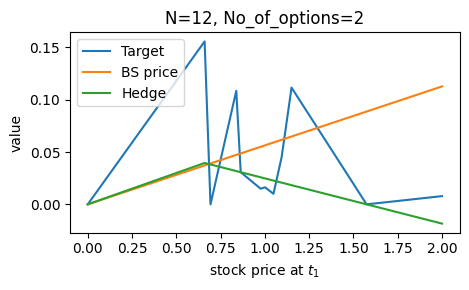


===Plot for 3 options==


 Short strikes:[0.         0.65985287 0.69305573]



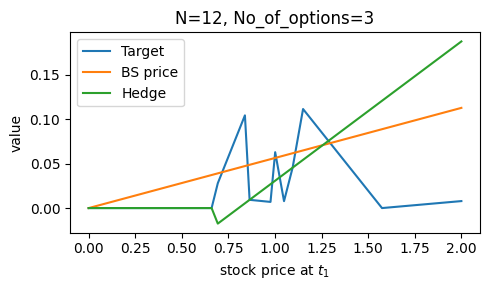


===Plot for 4 options==


 Short strikes:[0.         0.65985287 0.69305573 0.83860362]



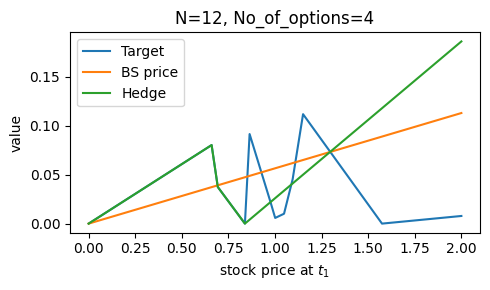


===Plot for 5 options==


 Short strikes:[0.         0.65985287 0.69305573 0.83860362 0.86371482]



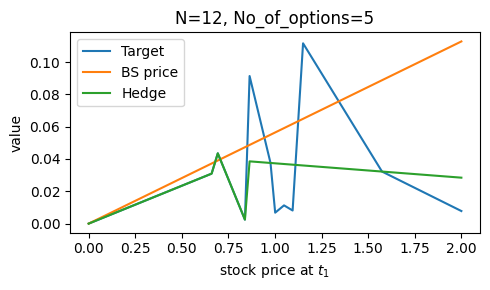


===Plot for 6 options==


 Short strikes:[0.         0.65985287 0.69305573 0.83860362 0.86371482 0.97595447]



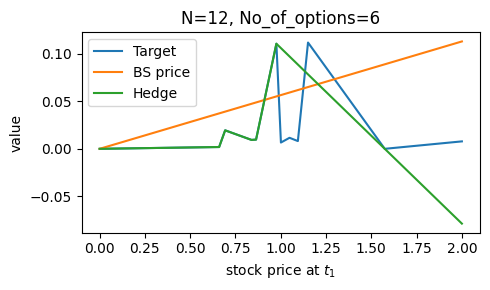


===Plot for 7 options==


 Short strikes:[0.         0.65985287 0.69305573 0.83860362 0.86371482 0.97595447
 1.00102542]



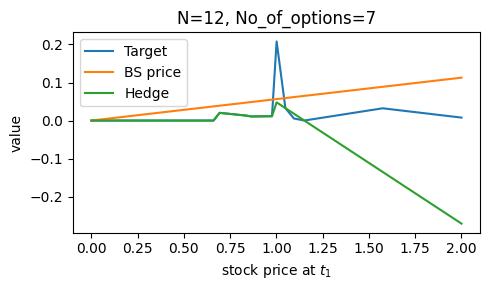


===Plot for 8 options==


 Short strikes:[0.         0.65985287 0.69305573 0.83860362 0.86371482 0.97595447
 1.00102542 1.0484879 ]



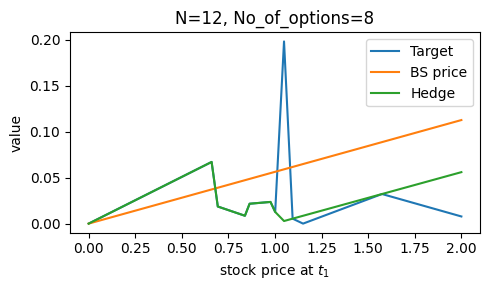


===Plot for 9 options==


 Short strikes:[0.         0.65985287 0.69305573 0.83860362 0.86371482 0.97595447
 1.00102542 1.0484879  1.09459717]



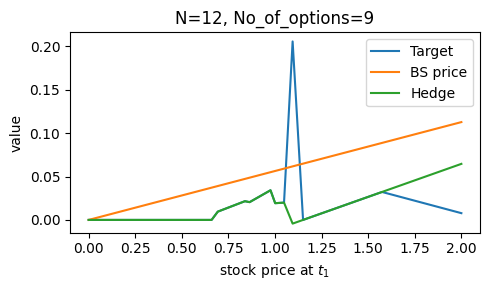


===Plot for 10 options==


 Short strikes:[0.         0.65985287 0.69305573 0.83860362 0.86371482 0.97595447
 1.00102542 1.0484879  1.09459717 1.15062857]



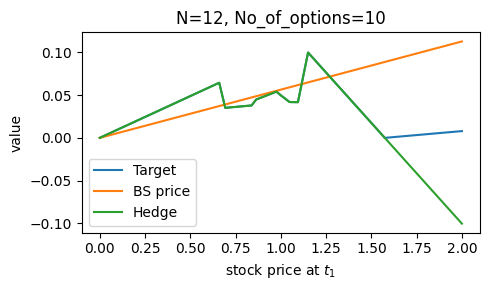


===Plot for 11 options==


 Short strikes:[0.         0.65985287 0.69305573 0.83860362 0.86371482 0.97595447
 1.00102542 1.0484879  1.09459717 1.15062857 1.57436388]



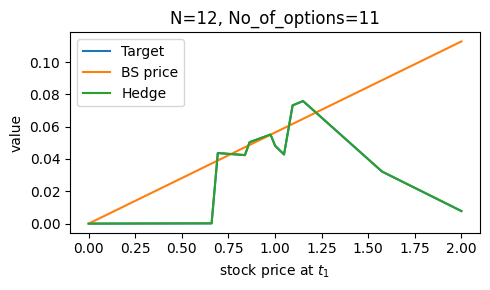


===Plot for 12 options==


 Short strikes:[0.         0.65985287 0.69305573 0.83860362 0.86371482 0.97595447
 1.00102542 1.0484879  1.09459717 1.15062857 1.57436388 2.00024222]



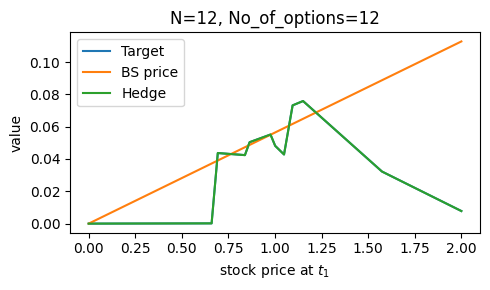

In [42]:
for idx, weights in enumerate(Weights_opt_list):
    Weights_opt_without_bounds = weights#result_data_no_bounds["w_opt"]
    P_matrix_no_bounds = p_matrix_list[idx]
   
    print(f"\n===Plot for {idx+1} options==\n")
    
    short_strikes = short_strike_range[:len( Weights_opt_without_bounds)-1]
    

    print(f"\n Short strikes:{short_strikes}\n")
    
    plot_one_run( K1,
        K2,
        truncation_range,
        N,
        Weights_opt_without_bounds,
        P_matrix_no_bounds,
        marg,
        K,
        T_GRID,
        sigma,
        r,
        run_idx=None,
        fname='Conditional_plot_no_bounds',
        show=True,
        no_of_options=len(short_strikes),
        short_strikes= short_strikes,
        asian_payoff=Asian_option_payoff,
        bs_call=BS_call,

    )

In [32]:
 data = {"Weights_opt_list":Weights_opt_list,
    "Objective_value_list":Objective_value_list,
    "p_matrix_list":p_matrix_list,
    "result_dict_list":result_dict_list}

In [34]:
import pickle
# with open('Data_max_min_BS_Forward_nonabs.pkl','wb') as f:
#     pickle.dump(data,f)

In [35]:
with open('Data_max_min_BS_Forward_nonabs.pkl','rb') as f:
    data_max_min = pickle.load(f)

In [66]:
data_max_min['Objective_value_list']

[-0.030814768093567615,
 -0.03115062523696305,
 -0.03483893192155169,
 -0.03267252173616772,
 -0.029423087895660647,
 -0.03316020933537941,
 -0.02234900821982918,
 -0.02394485152261198,
 -0.021073308424397745,
 -8.052070692518744e-06,
 -0.0,
 -0.0]

**SOLVE THE MAXIMIZATION PROBLEM WITH WEIGHTS FROM MAX-MIN**

In [43]:
Objective_value_max_list = []
p_matrix_max_list = []
result_max_dict_list = []    

for idx,weights in enumerate(Weights_opt_list):
    no_of_options = len(weights) -1
    short_strikes = short_strike_range[:no_of_options]
    
    print(f"\n=====Experiment for number of options:{no_of_options}======\n")
    
    M_bound = 10
   

    print(f"\n Weights:{weights}\n")
    
    results_max_prob = solve_max_problem_gurobi(M_bound,
        K1, K2,
        weights, short_strikes, K,
        marg, 0)
    
    
    Objective_value_max_list.append(results_max_prob['call_value'])
    p_matrix_max_list.append(results_max_prob['p_matrix'])
    result_max_dict_list.append(results_max_prob)
    
    
    print(f"\n Objective value from max problem:{results_max_prob['call_value']}\n")


=====Experiment for number of options:1======


 Weights:[ 0.06058666 -0.03848327]

0.04809669833277935

 Objective value from max problem:0.04809669833277935


=====Experiment for number of options:2======


 Weights:[ 0.          0.05994778 -0.10320228]

0.047844661095582455

 Objective value from max problem:0.047844661095582455


=====Experiment for number of options:3======


 Weights:[ 0.00000000e+00  1.46173544e-07 -5.26773414e-01  6.83602881e-01]

0.05428286589974808

 Objective value from max problem:0.05428286589974808


=====Experiment for number of options:4======


 Weights:[ 0.          0.12136342 -1.40911266  1.03130413  0.41635727]

0.054458614109453914

 Objective value from max problem:0.054458614109453914


=====Experiment for number of options:5======


 Weights:[ 0.          0.04687133  0.33194071 -0.66074328  1.71810001 -1.44505087]

0.05293508057022167

 Objective value from max problem:0.05293508057022167


=====Experiment for number of options:6======


 Weigh

In [44]:
Objective_value_max_list

[0.04809669833277935,
 0.047844661095582455,
 0.05428286589974808,
 0.054458614109453914,
 0.05293508057022167,
 0.07277757119683388,
 0.05908211664758129,
 0.05297943148685713,
 0.054162085079933225,
 0.062261773772629925,
 0.06350928659793667,
 0.06350928659793667]

In [55]:
Objective_value_list

[-0.030814768093567615,
 -0.03115062523696305,
 -0.03483893192155169,
 -0.03267252173616772,
 -0.029423087895660647,
 -0.03316020933537941,
 -0.02234900821982918,
 -0.02394485152261198,
 -0.021073308424397745,
 -8.052070692518744e-06,
 -0.0,
 -0.0]

In [65]:
solve_min_LP(K1,
    K2,
    marg[0],
    marg[1],
    short_strike_range[:2],
    K,
    p_matrix_list[2],)

{'objective': 0.03492045803719831,
 'Z': array([0.00000000e+00, 8.15261156e-05, 1.84330340e-03, 9.77309126e-03,
        0.00000000e+00, 3.78852373e-03, 3.20960758e-03, 3.52049476e-03,
        0.00000000e+00, 9.05915029e-03, 3.63138989e-03, 1.33710121e-05]),
 'W': array([ 0.        , -0.03439778,  0.19122739]),
 'status': 'optimal'}